# ETL - Extract, Transform, Load

### Extract Data

In [388]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

# 1000 Ω load
data_1k_load = pd.read_csv(url_1k, skiprows=17, usecols=[0, 1, 2])
data_1k_load.columns = ["time_secs", "dac_volts", "shunt_volts"]

# 2000 Ω load
data_2k_load = pd.read_csv(url_2k, skiprows=17, usecols=[0, 1, 2])
data_2k_load.columns = ["time_secs", "dac_volts", "shunt_volts"]

# 4700 Ω load
data_4k7_load = pd.read_csv(url_4k7, skiprows=17, usecols=[0, 1, 2])
data_4k7_load.columns = ["time_secs", "dac_volts", "shunt_volts"]

Text(0.5, 0, 'seconds')

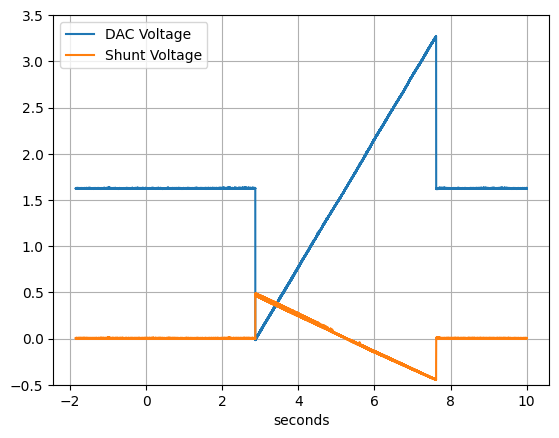

In [389]:
ax = data_1k_load.rename(columns={
    "dac_volts": "DAC Voltage",
    "shunt_volts": "Shunt Voltage"
}).plot(
    x="time_secs",
    y=["DAC Voltage", "Shunt Voltage"],
    grid=True,
    ylim=(-0.5, 3.5)
)

ax.set_xlabel("seconds")

### Transform Data

In [390]:
# Detecta região de rampa (ou, remove "regime em repouso") a partir de variação abrupta no DAC (indicando início e fim da rampa)

def extract_ramp_region(df, column, trigger_threshold):

    data = df.copy()

    diff = data[column].diff().abs()

    transition_points = diff[diff > trigger_threshold].index

    start = transition_points[0] + 2
    end = transition_points[-1] - 2

    return data.loc[start:end].copy()

In [391]:
# Analisa apenas o DAC pois o importante é descobrir o index de início e fim da rampa.
# Os indexes obtidos aplica-se também às series do shunt, para manter a fase entre sinais.

data_1k_load = extract_ramp_region(data_1k_load, column="dac_volts", trigger_threshold=0.5)
data_2k_load = extract_ramp_region(data_2k_load, column="dac_volts", trigger_threshold=0.5)
data_4k7_load = extract_ramp_region(data_4k7_load, column="dac_volts", trigger_threshold=0.5)

<Axes: title={'center': 'Current [mA]'}, xlabel='time_secs'>

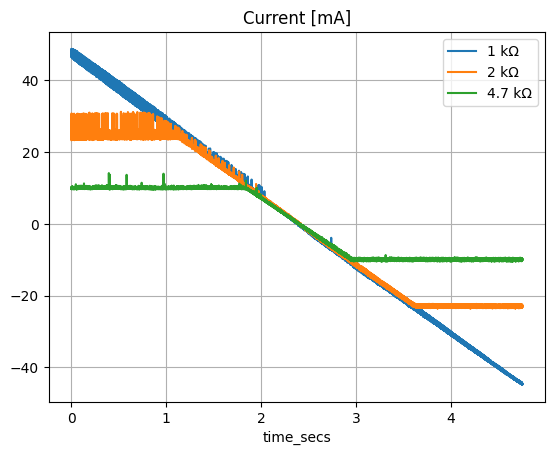

In [392]:
# A partir da tensão no shunt, calcula-se a corrente usando a lei de Ohm: I = V / R
# A corrente no shunt é a mesma da carga, dado que os dois estão em série.
# Multiplica-se por 1000 para converter de A para mA.

shunt_resistance = 10  # Ω

data_1k_load["current_mA"] = (data_1k_load["shunt_volts"] / shunt_resistance) * 1000
data_2k_load["current_mA"] = (data_2k_load["shunt_volts"] / shunt_resistance) * 1000
data_4k7_load["current_mA"] = (data_4k7_load["shunt_volts"] / shunt_resistance) * 1000

data_1k_load["time_secs"] = data_1k_load["time_secs"] - data_1k_load["time_secs"].iloc[0]
data_2k_load["time_secs"] = data_2k_load["time_secs"] - data_2k_load["time_secs"].iloc[0]
data_4k7_load["time_secs"] = data_4k7_load["time_secs"] - data_4k7_load["time_secs"].iloc[0]

ax = data_1k_load.plot(
    x="time_secs", y="current_mA", grid=True, title="Current [mA]", label="1 kΩ"
)

data_2k_load.plot(x="time_secs", y="current_mA", ax=ax, label="2 kΩ", grid=True)

data_4k7_load.plot(x="time_secs", y="current_mA", ax=ax, label="4.7 kΩ", grid=True)

In [393]:
# =========================================================
# Data discretization and statistical aggregation
# =========================================================

# The datasets from different load conditions are consolidated
# into a single dataframe for comparative analysis.
#
# The DAC voltage domain is discretized using uniform binning,
# grouping samples that belong to equivalent voltage intervals.
#
# For each DAC bin, the mean output current is calculated,
# reducing acquisition noise and small temporal variations.
#
# The resulting structure represents the average transfer
# characteristic of the FES output stage for each load.

dac_step = 0.01

load_1k_cmp = data_1k_load.copy()
load_2k_cmp = data_2k_load.copy()
load_4k7_cmp = data_4k7_load.copy()

load_1k_cmp["load_value"] = "1k"
load_2k_cmp["load_value"] = "2k"
load_4k7_cmp["load_value"] = "4k7"

all_currents = pd.concat([load_1k_cmp, load_2k_cmp, load_4k7_cmp])

all_currents["dac_bin"] = (all_currents["dac_volts"] // dac_step) * dac_step

all_currents.head()



,time_secs,dac_volts,shunt_volts,current_mA,load_value,dac_bin
58981,0.00000,-0.009531,0.468891,46.889063,1k,-0.01
58982,0.00008,-0.010313,0.477531,47.753125,1k,-0.02
58983,0.00016,-0.013281,0.472000,47.200000,1k,-0.02
58984,0.00024,-0.015938,0.468703,46.870312,1k,-0.02
58985,0.00032,-0.017656,0.464953,46.495313,1k,-0.02


In [394]:
all_current_comparison = all_currents.pivot_table(index="dac_bin", columns="load_value", values="current_mA", aggfunc="mean")
all_current_comparison.head()

load_value,1k,2k,4k7
dac_bin,,,
-0.03,NaN,24.277455,9.840365
-0.02,46.937600,24.329558,9.917024
-0.01,47.130724,24.466085,9.919587
0.00,46.845262,24.658353,9.930252
0.01,46.523013,24.434646,9.930973


# EDA - Exploratory Data Analysis



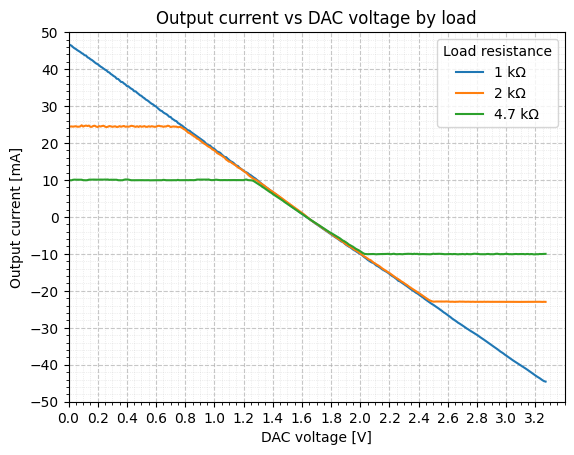

In [395]:
ax = all_current_comparison.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.set_title("Output current vs DAC voltage by load")
ax.legend(title="Load resistance")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ"], title="Load resistance")

In [396]:
all_current_comparison["max_current"] = all_current_comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].max(axis=1)
all_current_comparison["min_current"] = all_current_comparison[["1 kΩ", "2 kΩ", "4.7 kΩ"]].min(axis=1)

all_current_comparison["current_spread"] = all_current_comparison["max_current"] - all_current_comparison["min_current"]

all_current_comparison[["1 kΩ", "2 kΩ", "4.7 kΩ", "current_spread"]].head()

KeyError: "None of [Index(['1 kΩ', '2 kΩ', '4.7 kΩ'], dtype='str', name='load_value')] are in the [columns]"

In [ ]:
all_current_comparison["current_spread"].describe()

count    331.000000
mean      14.369634
std       11.803608
min        0.049576
25%        1.822758
50%       13.351757
75%       24.703259
max       37.211137
Name: current_spread, dtype: float64

<Axes: title={'center': 'Current spread between loads'}, xlabel='dac_bin'>

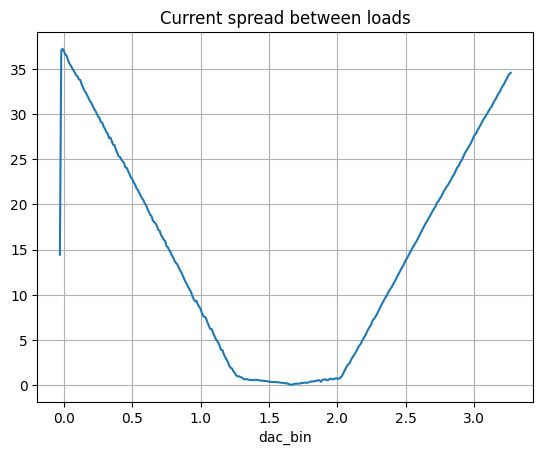

In [ ]:
all_current_comparison["current_spread"].plot(grid=True, title="Current spread between loads")

In [ ]:
data_1k_load["current_mA"].describe()

count    59406.000000
mean         0.790920
std         26.656282
min        -44.846875
25%        -22.371875
50%          0.320312
75%         23.834766
max         48.792187
Name: current_mA, dtype: float64